# Épaisseur corticale après JDAC et ses variantes (ds004332, pipeline rigide)

**Question.** Chaque condition corrige-t-elle le mouvement (l'épaisseur mesurée ne dépend plus du mouvement), le lisse-t-elle (elle abaisse l'épaisseur même sans mouvement), ou le sur-corrige-t-elle (elle inverse le lien) ?

**Cinq conditions** (toutes en rigide) : `brut`, `preproc`, `jdac` (complet), `jdac_antiartonly` (anti-artefact ×1), `jdac_nodenoise` (anti-artefact ×4, sans débruiteur).

**Unité.** Épaisseurs en **mm** ; mouvement = score Agitation (sans unité). Trois runs par sujet : run-01 immobile (still), run-02 (nodding), run-03 bougé (shaking).

**Sources** : brut `results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv` ; preproc/jdac `derivatives/ds004332/thickness/thickness_{preproc,jdac}_{lh,rh}.csv` ; variantes `derivatives/ds004332/thickness/thickness_jdac_{antiartonly,nodenoise}_{lh,rh}.csv` ; Agitation `results/ds004332/agitation/ds004332_agitation_clinica.csv` ; âge/sexe `raw_datasets/ds004332/participants.tsv`.

<style>
/* Présentation lisible sur un écran pendant la réunion. */
.jp-Notebook, .notebook-container { font-size: 16px; }
.jp-MarkdownOutput, .rendered_html { font-size: 17px; line-height: 1.65; }
.jp-MarkdownOutput h2, .rendered_html h2 {
  margin-top: 2.2em; padding-top: 0.45em; border-top: 2px solid #9aa7bd;
}
.jp-MarkdownOutput h3, .rendered_html h3 { margin-top: 1.6em; }
.jp-OutputArea, .output_area { margin: 1.1em 0 2.2em 0; }
.jp-RenderedHTMLCommon table, .rendered_html table { margin: 1.1em 0 1.8em 0; }
.question-box, .analysis-box {
  margin: 1.0em 0 1.3em 0; padding: 0.8em 1.0em; border-radius: 6px;
}
.question-box { background: #eef4ff; border-left: 5px solid #5277a8; }
.analysis-box { background: #f3f7f0; border-left: 5px solid #638657; }
</style>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML
from html import escape
import warnings; warnings.filterwarnings("ignore")

def show(df, question, analyse, fmt="{:.3f}"):
    # Question, tableau aéré, puis résultats en points courts.
    display(HTML(f'<div class="question-box"><b>Question</b><br>{escape(question)}</div>'))
    styled = (df.style.format(fmt, na_rep="—").set_table_styles([
        {"selector": "table", "props": "margin:12px 0 22px 0;border-collapse:collapse;"},
        {"selector": "th", "props": "background-color:#d9e1f2;padding:9px 14px;font-size:15px;"},
        {"selector": "td", "props": "padding:8px 14px;font-size:15px;text-align:right;"},
        {"selector": "tbody tr:nth-child(odd)", "props": "background-color:#f6f6f6;"}]))
    display(styled)
    points = analyse if isinstance(analyse, (list, tuple)) else [analyse]
    items = "".join(f"<li>{escape(str(point))}</li>" for point in points)
    display(HTML(f'<div class="analysis-box"><b>Résultats à retenir</b><ul>{items}</ul></div>'))

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
})

HOME  = Path.home()

def find_repo():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv").exists():
            return p
    fallback = HOME / "Documents/GitHub/jdac-motion-correction"
    if fallback.exists():
        return fallback
    return HOME / "Documents/jdac-motion-correction"

REPO  = find_repo()
DERIV = HOME / "Documents/derivatives/ds004332"
CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
SHORT = {"brut": "brut", "preproc": "prep", "jdac": "jdac",
         "jdac_antiartonly": "aa×1", "jdac_nodenoise": "nod×4"}
CONSIGNE = {"run-01": "still", "run-02": "nodding", "run-03": "shaking"}
WIDE = {"preproc": "thickness/thickness_preproc_{h}.csv",
        "jdac": "thickness/thickness_jdac_{h}.csv",
        "jdac_antiartonly": "thickness/thickness_jdac_antiartonly_{h}.csv",
        "jdac_nodenoise": "thickness/thickness_jdac_nodenoise_{h}.csv"}

def load_brut():
    d = pd.read_csv(REPO / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv")
    d = d[d["ThickAvg"] > 0].copy()
    d["run"] = d["subject"].str.split("_").str[1]
    d["subject"] = d["subject"].str.split("_").str[0]
    return d.rename(columns={"ThickAvg": "thickness"}).assign(condition="brut")[
        ["subject", "run", "thickness", "condition"]]

def load_wide(cond):
    frames = []
    for hemi in ["lh", "rh"]:
        w = pd.read_csv(DERIV / WIDE[cond].format(h=hemi), sep="\t")
        w = w.rename(columns={w.columns[0]: "id"})
        cols = [c for c in w.columns if c.endswith("_thickness") and "MeanThickness" not in c]
        long = w.melt(id_vars="id", value_vars=cols, value_name="thickness")
        long["subject"] = long["id"].str.split("_").str[0]
        long["run"] = long["id"].str.split("_").str[1]
        frames.append(long)
    return pd.concat(frames, ignore_index=True).assign(condition=cond)[
        ["subject", "run", "thickness", "condition"]]

# Épaisseur corticale moyenne (mm) par acquisition (moyenne des régions des 2 hémisphères)
thick = pd.concat([load_brut()] + [load_wide(c) for c in CONDITIONS if c != "brut"], ignore_index=True)
thick = thick[thick["thickness"] > 0]
g = thick.groupby(["subject", "run", "condition"], observed=True)["thickness"].mean().reset_index()

agit = pd.read_csv(REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv") \
         .rename(columns={"condition": "run", "sub": "subject", "motion": "agitation"})
demog = pd.read_csv(HOME / "Documents/raw_datasets/ds004332/participants.tsv", sep="\t") \
          .rename(columns={"participant_id": "subject"})
demog["sex_bin"] = (demog["sex"] == "F").astype(int)
g = g.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")
g = g.merge(demog[["subject", "age", "sex_bin"]], on="subject", how="left")
g["consigne"] = g["run"].map(CONSIGNE)
g["condition"] = pd.Categorical(g["condition"], categories=CONDITIONS, ordered=True)

print("Acquisitions par condition (une par sujet × run) :")
print(g.groupby("condition", observed=True).size().to_string())
print("\nÉpaisseur = moyenne des régions FreeSurfer, en mm. Une ligne = un sujet × run × condition.")

Acquisitions par condition (une par sujet × run) :
condition
brut                65
preproc             64
jdac                64
jdac_antiartonly    66
jdac_nodenoise      65

Épaisseur = moyenne des régions FreeSurfer, en mm. Une ligne = un sujet × run × condition.


## A. Le traitement modifie-t-il déjà le scan de référence ?

`run-01` est l'acquisition avec consigne immobile et le plus faible mouvement. Ce n'est pas une vérité parfaite, mais c'est notre **référence opérationnelle**. Un correcteur ne devrait pas la modifier fortement.

Pour chaque sujet et chaque condition, l'épaisseur globale est la moyenne non pondérée des 68 épaisseurs régionales FreeSurfer. La comparaison est maintenant **appariée** : une condition n'est comparée au brut que chez les sujets disposant des deux mesures `run-01`.

Pour un sujet $s$ et une condition $c$ :

$$\Delta_{s,c}=\bar T_{s,run01,c}-\bar T_{s,run01,brut}$$

Une valeur négative signifie que le traitement amincit le cortex mesuré sur le scan de référence.

In [2]:
imm = g[g["consigne"] == "still"].pivot_table(
    index="subject", columns="condition", values="thickness", observed=True
)
rows = []
for c in CONDITIONS:
    pair = imm[["brut", c]].dropna() if c != "brut" else imm[["brut"]].dropna()
    if c == "brut":
        delta = pair["brut"] * 0
        treated = pair["brut"]
    else:
        delta = pair[c] - pair["brut"]
        treated = pair[c]
    rows.append({
        "condition": c,
        "n paires": len(pair),
        "brut run-01 apparié (mm)": pair["brut"].mean(),
        "condition run-01 (mm)": treated.mean(),
        "différence appariée moyenne (mm)": delta.mean(),
        "différence appariée médiane (mm)": delta.median(),
        "différence moyenne (%)": 100 * delta.mean() / pair["brut"].mean(),
    })
tA = pd.DataFrame(rows).set_index("condition").reindex(CONDITIONS)

o = tA["différence appariée moyenne (mm)"].drop("brut")
analyse = (f"Chez les mêmes sujets, les quatre traitements déplacent l'épaisseur du run-01. "
           f"L'effet moyen va de {o.max():+.3f} à {o.min():+.3f} mm; le plus fort est {o.idxmin()}. "
           f"Comme la comparaison est appariée, cet écart ne vient pas d'un changement de composition du groupe. "
           f"Il mesure l'effet propre du traitement sur la référence opérationnelle.")
show(tA, "Chez les mêmes sujets, le traitement change-t-il l'épaisseur du run-01 par rapport au brut ?", analyse,
     {"n paires": "{:.0f}", "brut run-01 apparié (mm)": "{:.3f}",
      "condition run-01 (mm)": "{:.3f}", "différence appariée moyenne (mm)": "{:+.3f}",
      "différence appariée médiane (mm)": "{:+.3f}", "différence moyenne (%)": "{:+.1f}"})

,n paires,brut run-01 apparié (mm),condition run-01 (mm),différence appariée moyenne (mm),différence appariée médiane (mm),différence moyenne (%)
condition,,,,,,
brut,22,2.595,2.595,+0.000,+0.000,+0.0
preproc,21,2.594,2.518,-0.076,-0.079,-2.9
jdac,22,2.595,2.435,-0.160,-0.136,-6.2
jdac_antiartonly,22,2.595,2.418,-0.177,-0.167,-6.8
jdac_nodenoise,21,2.594,2.378,-0.216,-0.183,-8.3


## B. Les acquisitions traitées se rapprochent-elles de `raw/run-01` ?

La référence horizontale zéro est, pour chaque sujet, sa propre épaisseur globale `raw/run-01`. Chaque point représente :

$$\Delta_{s,r,c}=\bar T_{s,r,c}-\bar T_{s,run01,brut}$$

- proche de zéro : épaisseur globale proche de la référence opérationnelle ;
- négatif : cortex mesuré plus mince que la référence ;
- positif : cortex mesuré plus épais.

Cette figure remplace les 22 petits panneaux. Elle montre la distribution entre sujets et permet de voir simultanément le déplacement du run-01 et celui des runs bougés.

**Lecture attendue du boxplot.** Les variantes sans débruiteur ont deux effets successifs :

- sur le `run-01`, elles déplacent les boîtes sous zéro : elles **diminuent l'épaisseur mesurée alors qu'il n'y a presque aucun mouvement à corriger** ;
- lorsque le mouvement augmente, surtout après quatre passages, les boîtes remontent : l'épaisseur augmente avec Agitation et le lien attendu finit par s'inverser.

Le boxplot démontre donc un **offset d'amincissement**, puis une **sur-correction dépendante du mouvement**. Il ne démontre pas à lui seul que l'anatomie régionale est restaurée : des erreurs positives et négatives peuvent s'annuler dans la moyenne globale.

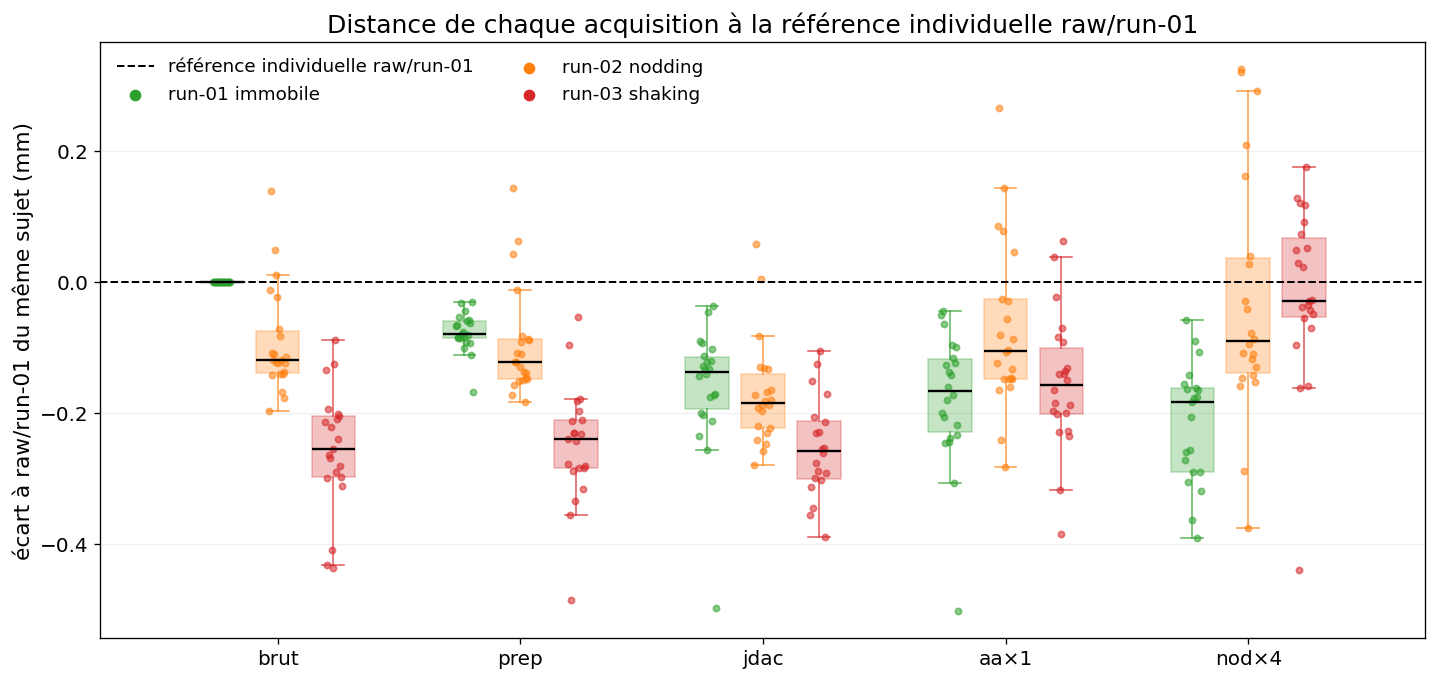

consigne,nodding,shaking,still
condition,,,
brut,-0.177,-0.205,+0.000
preproc,-0.147,-0.210,-0.062
jdac,-0.187,-0.214,-0.036
jdac_antiartonly,-0.148,-0.149,-0.099
jdac_nodenoise,-0.086,-0.042,-0.106


In [3]:
raw_still = (g[(g["condition"] == "brut") & (g["consigne"] == "still")]
             [["subject", "thickness"]].rename(columns={"thickness": "raw_run01"}))
rel = g.merge(raw_still, on="subject", how="inner")
rel["écart à raw/run-01 (mm)"] = rel["thickness"] - rel["raw_run01"]

colors = {"still": "tab:green", "nodding": "tab:orange", "shaking": "tab:red"}
offsets = {"still": -0.23, "nodding": 0.0, "shaking": 0.23}
fig, ax = plt.subplots(figsize=(12.5, 6.2))
for i, c in enumerate(CONDITIONS):
    for cons in ["still", "nodding", "shaking"]:
        values = rel[(rel["condition"] == c) & (rel["consigne"] == cons)]["écart à raw/run-01 (mm)"].dropna()
        if values.empty:
            continue
        pos = i + offsets[cons]
        bp = ax.boxplot(values, positions=[pos], widths=0.18, patch_artist=True,
                        showfliers=False, medianprops={"color": "black", "lw": 1.4})
        bp["boxes"][0].set(facecolor=colors[cons], alpha=0.28, edgecolor=colors[cons])
        for item in bp["whiskers"] + bp["caps"]:
            item.set(color=colors[cons], alpha=0.7)
        jitter = np.linspace(-0.035, 0.035, len(values))
        ax.scatter(pos + jitter, values, s=14, color=colors[cons], alpha=0.55)
ax.axhline(0, color="black", ls="--", lw=1.2, label="référence individuelle raw/run-01")
for cons in colors:
    ax.scatter([], [], color=colors[cons], label={"still":"run-01 immobile", "nodding":"run-02 nodding", "shaking":"run-03 shaking"}[cons])
ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([SHORT[c] for c in CONDITIONS])
ax.set_ylabel("écart à raw/run-01 du même sujet (mm)")
ax.set_title("Distance de chaque acquisition à la référence individuelle raw/run-01")
ax.legend(fontsize=11, ncol=2, frameon=False)
ax.grid(axis="y", alpha=0.18)
plt.tight_layout(pad=2.0); plt.show()

pv = g.pivot_table(index=["subject", "condition"], columns="consigne", values="thickness", observed=True)

case19 = (rel[rel["subject"] == "sub-19"].pivot_table(
    index="condition", columns="consigne", values="écart à raw/run-01 (mm)", observed=True
).reindex(CONDITIONS))
show(case19, "Pour sub-19, à quelle distance chaque run et chaque traitement se trouvent-ils de raw/run-01 ?",
     "Ce tableau numérique accompagne le montage des trois runs de sub-19. Une valeur proche de zéro est souhaitable; "
     "une valeur positive importante indique une sur-correction et une valeur négative importante un amincissement.",
     "{:+.3f}")

Le tableau suivant complète la figure. Pour chaque sujet :

$$Écart_{c}=T_{run01,c}-T_{run03,c}$$

Seuls les sujets chez qui le raw montre le comportement attendu ($Écart_{brut}>0$, donc shaking plus mince que run-01) sont classés :

- **amélioré** : $0 \leq Écart_c < Écart_{brut}$ ; le shaking se rapproche du run-01 sans le dépasser ;
- **sur-corrigé** : $Écart_c<0$ ; le shaking devient plus épais que le run-01 ;
- **inchangé ou pire** : $Écart_c\geq Écart_{brut}$.

B reste une analyse d'épaisseur globale. La section E vérifie ensuite la fidélité région par région.

In [4]:
ec = pv.reset_index().dropna(subset=["still", "shaking"])
ec["ecart"] = ec["still"] - ec["shaking"]          # > 0 : le mouvement amincit
w = ec.pivot(index="subject", columns="condition", values="ecart")

rows = []
for c in CONDITIONS:
    if c == "brut":
        continue
    p = w[["brut", c]].dropna()
    p = p[p["brut"] > 0]
    rows.append({"condition": c, "n sujets": len(p),
                 "améliorés": int(((p[c] >= 0) & (p[c] < p["brut"])).sum()),
                 "sur-corrigés": int((p[c] < 0).sum()),
                 "inchangés/pires": int((p[c] >= p["brut"]).sum()),
                 "écart médian brut (mm)": p["brut"].median(),
                 "écart médian condition (mm)": p[c].median()})
tB = pd.DataFrame(rows).set_index("condition")

analyse = (f"preproc et jdac réduisent l'écart chez la majorité ({tB.loc['preproc','améliorés']:.0f} et "
           f"{tB.loc['jdac','améliorés']:.0f} sujets améliorés sur ~{tB.loc['jdac','n sujets']:.0f}), avec peu de sur-corrigés. "
           f"Les variantes sans débruiteur sur-corrigent la majorité : {tB.loc['jdac_antiartonly','sur-corrigés']:.0f} sujets "
           f"pour antiartonly, {tB.loc['jdac_nodenoise','sur-corrigés']:.0f} pour nodenoise (le bougé devient plus épais que "
           f"l'immobile). Réserve : cet écart mélange récupération et offset — la section E tranche par région.")
show(tB, "Chez combien de sujets l'écart immobile − bougé se réduit vraiment (sans s'inverser) ?", analyse,
     {"n sujets": "{:.0f}", "améliorés": "{:.0f}", "sur-corrigés": "{:.0f}", "inchangés/pires": "{:.0f}",
      "écart médian brut (mm)": "{:.3f}", "écart médian condition (mm)": "{:.3f}"})

,n sujets,améliorés,sur-corrigés,inchangés/pires,écart médian brut (mm),écart médian condition (mm)
condition,,,,,,
preproc,19,16,1,2,0.239,0.148
jdac,19,15,3,1,0.239,0.118
jdac_antiartonly,21,7,14,0,0.255,-0.033
jdac_nodenoise,20,1,19,0,0.247,-0.226


## C. Après traitement, l'épaisseur reste-t-elle associée au mouvement ?

Le mot **prédire** signifie ici : « connaître le score Agitation aide-t-il à expliquer les différences d'épaisseur entre les acquisitions ? ». Il ne s'agit pas de prédire l'épaisseur d'un futur patient.

Chaque condition est analysée séparément. Pour le sujet $i$ et son acquisition $j$, le modèle complet est :

$$T_{ij}=\beta_0+\beta_{âge}âge_i+\beta_{sexe}sexe_i+\beta_{agit}Agitation_{ij}+u_i+\varepsilon_{ij}$$

- $T_{ij}$ : épaisseur moyenne des 68 régions pour cette acquisition ;
- $\beta_{agit}$ : changement moyen d'épaisseur, en mm, pour +1 point d'Agitation ;
- $u_i$ : **intercept aléatoire du sujet**. Il autorise chaque sujet à avoir son niveau d'épaisseur habituel, tout en estimant une pente Agitation commune. Dans le code : `groups=d["subject"]` dans `mixedlm` ;
- $\varepsilon_{ij}$ : variation restante non expliquée.

Deux modèles emboîtés sont comparés :

- **M0** : âge + sexe + intercept aléatoire du sujet ;
- **M1** : M0 + Agitation.

La p-value vient d'un test du rapport de vraisemblance entre M0 et M1. Sous l'hypothèse « Agitation n'ajoute réellement aucune information », elle mesure à quel point le gain d'ajustement observé serait inhabituel. Une petite valeur, par exemple `< 0,05`, indique que l'ajout d'Agitation améliore clairement le modèle. Une valeur plus grande ne prouve pas l'absence d'effet : elle indique que les données ne permettent pas de le distinguer clairement du bruit.

Les lignes diffèrent parce que chaque traitement modifie les épaisseurs, leur relation au mouvement et leur variabilité. La p-value dépend à la fois de la taille du coefficient, de la dispersion des données et du nombre d'acquisitions disponibles.

In [5]:
def fit(formula, d):
    return smf.mixedlm(formula, d, groups=d["subject"]).fit(reml=False, method="powell", disp=False)

rows = []
for c in CONDITIONS:
    d = g[g["condition"] == c].dropna(subset=["age", "sex_bin", "agitation", "thickness"])
    m0 = fit("thickness ~ age + sex_bin", d)
    m1 = fit("thickness ~ age + sex_bin + agitation", d)
    lr = 2 * (m1.llf - m0.llf)
    coef = m1.params["agitation"]
    se = m1.bse["agitation"]
    rows.append({"condition": c, "n acquisitions": d.groupby(["subject", "run"]).ngroups,
                 "coef Agitation (mm/point)": coef,
                 "IC95 bas": coef - 1.96 * se, "IC95 haut": coef + 1.96 * se,
                 "p ajout Agitation (M1 vs M0)": stats.chi2.sf(lr, 1),
                 "sens": "amincit" if coef < 0 else "épaissit"})
tC = pd.DataFrame(rows).set_index("condition")

ns = [c for c in CONDITIONS if tC.loc[c, "p ajout Agitation (M1 vs M0)"] >= 0.05]
analyse = [
    f"Brut : le mouvement est associé à un amincissement (coef {tC.loc['brut','coef Agitation (mm/point)']:+.4f} mm/point, p={tC.loc['brut','p ajout Agitation (M1 vs M0)']:.1g}).",
    f"JDAC : association résiduelle plus faible (p={tC.loc['jdac','p ajout Agitation (M1 vs M0)']:.2g}). Conditions sans effet clairement distinguable : {', '.join(ns) if ns else 'aucune'}.",
    f"Antiartonly et nodenoise inversent la pente ; nodenoise atteint {tC.loc['jdac_nodenoise','coef Agitation (mm/point)']:+.4f} mm/point (p={tC.loc['jdac_nodenoise','p ajout Agitation (M1 vs M0)']:.1g}), signe de sur-correction.",
    "Une pente faible ne suffit pas si le traitement déplace aussi le scan de référence : lire avec A et E."
]
show(tC, "Après la condition, ajouter le score de mouvement améliore-t-il encore le modèle ?", analyse,
     {"n acquisitions": "{:.0f}", "coef Agitation (mm/point)": "{:+.4f}",
      "IC95 bas": "{:+.4f}", "IC95 haut": "{:+.4f}",
      "p ajout Agitation (M1 vs M0)": "{:.2g}", "sens": "{}"})

,n acquisitions,coef Agitation (mm/point),IC95 bas,IC95 haut,p ajout Agitation (M1 vs M0),sens
condition,,,,,,
brut,65,-0.0662,-0.1096,-0.0228,6.6e-05,amincit
preproc,64,-0.0308,-0.0622,+0.0006,0.028,amincit
jdac,64,-0.0203,-0.0441,+0.0035,0.11,amincit
jdac_antiartonly,66,+0.0253,-0.0031,+0.0536,0.081,épaissit
jdac_nodenoise,65,+0.0923,+0.0600,+0.1246,7.1e-07,épaissit


## D. L'image et les contours ressemblent-ils davantage à la référence ?

Le SSIM (*Structural Similarity Index*) compare deux images dans des fenêtres locales, puis moyenne le résultat. Pour deux fenêtres $x$ et $y$ :

$$SSIM(x,y)=\frac{(2\mu_x\mu_y+C_1)(2\sigma_{xy}+C_2)}{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}$$

- $\mu_x,\mu_y$ : intensités moyennes locales (luminance) ;
- $\sigma_x,\sigma_y$ : contrastes locaux ;
- $\sigma_{xy}$ : structures locales variant ensemble ;
- $C_1,C_2$ : petites constantes de stabilité.

Le score va approximativement de 0 à 1 dans ce contexte ; 1 signifie que les deux images comparées sont identiques. Avant le calcul, chaque volume est normalisé robustement entre ses percentiles cérébraux 1 et 99, ramené dans `[0,1]`, et comparé dans la boîte englobante du cerveau commun.

Trois lectures complémentaires sont conservées dans **un seul tableau** :

1. **SSIM image vs run-01 preproc** : ressemblance de toute l'image bougée au run-01 de référence ; un lissage peut artificiellement améliorer ce score.
2. **SSIM gradient vs run-01 preproc** : même référence, mais sur la magnitude du gradient $\|\nabla I\|$, qui met davantage l'accent sur les frontières et les contours.
3. **SSIM gradient intra-condition** : le run bougé d'une condition est comparé au run-01 ayant subi la même condition, par exemple `JDAC run-03` contre `JDAC run-01`. Cela réduit la différence d'apparence propre à la méthode (contraste, intensité, lissage), mais la référence est elle-même traitée : ce score mesure la cohérence interne, pas la vérité anatomique.

Les images rigides sont sur la même grille ; aucun recalage supplémentaire n'est appliqué. Métriques calculées par `compute_image_metrics.py`.

In [6]:
im = pd.read_csv(REPO / "results/ds004332/phase4_compare_3bras/image_metrics.csv")
IMGCONDS = ["preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
lab = {"run-02": "nodding (mvt modéré)", "run-03": "shaking (fort mvt)"}
agg = im.groupby(["condition", "run"])[["clean_ssim_img", "clean_ssim_grad", "intra_ssim_grad"]].mean()
s = agg.xs("run-03", level="run")   # au fort mouvement, pour l'analyse

A_img = (f"Contre le scan propre, la ressemblance d'image monte légèrement après correction au fort mouvement "
         f"(preproc {s.loc['preproc','clean_ssim_img']:.3f}, jdac {s.loc['jdac','clean_ssim_img']:.3f}, "
         f"nodenoise {s.loc['jdac_nodenoise','clean_ssim_img']:.3f}), mais l'image seule ne sépare pas correction et lissage.")
A_grad = (f"Sur les contours, contre le propre non traité, aucune condition ne dépasse nettement preproc au fort mouvement "
          f"(preproc {s.loc['preproc','clean_ssim_grad']:.3f}, jdac {s.loc['jdac','clean_ssim_grad']:.3f}, "
          f"nodenoise {s.loc['jdac_nodenoise','clean_ssim_grad']:.3f}). Ce test mélange correction et changement d'intensité, "
          f"d'où le tableau intra ci-dessous.")
A_intra = (f"En comparaison intra-condition (même traitement pour le run bougé et son run-01), jdac gagne en cohérence des contours au fort mouvement "
           f"({s.loc['jdac','intra_ssim_grad']:.3f} vs preproc {s.loc['preproc','intra_ssim_grad']:.3f}) = mouvement réduit. "
           f"nodenoise ne gagne pas ({s.loc['jdac_nodenoise','intra_ssim_grad']:.3f}, ≤ preproc). Attention : cette comparaison "
           f"mesure une cohérence interne; elle ne prouve pas que les contours traités sont anatomiquement vrais.")

d_table = agg.reset_index().rename(columns={
    "condition": "condition", "run": "run",
    "clean_ssim_img": "SSIM image vs run-01 preproc",
    "clean_ssim_grad": "SSIM gradient vs run-01 preproc",
    "intra_ssim_grad": "SSIM gradient vs run-01 même condition",
}).set_index(["condition", "run"])
analyse = [A_img, A_grad, A_intra]
show(d_table, "La correction rapproche-t-elle l'image et ses contours du run-01 du même sujet ?",
     analyse, "{:.3f}")

## E. Les 68 épaisseurs régionales se rapprochent-elles de la référence ?

`raw/run-01` du même sujet est la **référence opérationnelle** : c'est le scan le moins traité et avec consigne immobile, mais pas une vérité anatomique parfaite.

Pour un sujet $s$, une condition $c$, un run bougé $k$ et les $R=68$ régions, on note $T_{s,k,c,r}$ l'épaisseur de la région $r$.

### 1. Distorsion du scan de référence

$$Offset_{s,c}=\frac{1}{R}\sum_r|T_{s,run01,c,r}-T_{s,run01,brut,r}|$$

Cette quantité mesure ce que la condition change déjà sur le run-01. Elle est absolue et régionale, contrairement au déplacement global signé de A : les différences positives et négatives ne peuvent pas se compenser.

### 2. Écart résiduel entre runs dans la même condition

$$Résiduel_{s,k,c}=\frac{1}{R}\sum_r|T_{s,k,c,r}-T_{s,run01,c,r}|$$

Les deux scans ont subi le même traitement. Un déplacement constant propre à la condition se compense en grande partie ; cette mesure décrit surtout le motif régional restant entre le run bougé et le run-01 traité.

### 3. Erreur totale à la référence opérationnelle

$$Erreur_{s,k,c}=\frac{1}{R}\sum_r|T_{s,k,c,r}-T_{s,run01,brut,r}|$$

C'est le critère principal : l'épaisseur régionale du run bougé traité se rapproche-t-elle réellement de `raw/run-01` ? Les trois mesures sont nécessaires pour distinguer une vraie réduction du mouvement d'un simple déplacement ou d'une compensation. Elles sont d'abord calculées par sujet, puis moyennées entre les sujets. Métriques calculées par `compute_recovery.py`.

In [7]:
rec = pd.read_csv(REPO / "results/ds004332/phase4_compare_3bras/recovery_metrics.csv")
RCONDS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
for run, cons in [("run-03", "shaking (fort mouvement)"), ("run-02", "nodding (mouvement modéré)")]:
    t = (rec[rec["run"] == run].groupby("condition")[["mae_within", "mae_truth", "offset"]].mean().reindex(RCONDS))
    bt, bw = t.loc["brut", "mae_truth"], t.loc["brut", "mae_within"]
    analyse = [
        f"Aucune condition ne descend sous l'erreur du brut à la référence opérationnelle ({bt:.3f} mm) : JDAC {t.loc['jdac','mae_truth']:.3f} mm, nodenoise {t.loc['jdac_nodenoise','mae_truth']:.3f} mm.",
        f"Net d'offset, nodenoise augmente l'écart régional ({t.loc['jdac_nodenoise','mae_within']:.3f} contre {bw:.3f} mm en brut).",
        f"Le preprocessing est le seul à réduire légèrement cet écart ({t.loc['preproc','mae_within']:.3f} mm)."
    ]
    t.columns = ["écart résiduel intra-condition (mm)", "erreur à raw/run-01 (mm)", "distorsion de run-01 (mm)"]
    show(t, f"Scan {cons} : l'épaisseur régionale se rapproche-t-elle de la référence raw/run-01 ?", analyse, "{:.3f}")

,écart résiduel intra-condition (mm),erreur à raw/run-01 (mm),distorsion de run-01 (mm)
condition,,,
brut,0.315,0.315,0.000
preproc,0.271,0.311,0.087
jdac,0.317,0.373,0.232
jdac_antiartonly,0.341,0.314,0.193
jdac_nodenoise,0.415,0.336,0.255


,écart résiduel intra-condition (mm),erreur à raw/run-01 (mm),distorsion de run-01 (mm)
condition,,,
brut,0.256,0.256,0.000
preproc,0.252,0.264,0.088
jdac,0.307,0.350,0.230
jdac_antiartonly,0.328,0.298,0.193
jdac_nodenoise,0.323,0.320,0.255


## Synthèse

Bilan des cinq conditions sur les questions A à E. Les deux variantes sans débruiteur (antiartonly ×1, nodenoise ×4) **sur-corrigent** : elles inversent le lien mouvement–épaisseur (C, coefficient positif) et, une fois l'offset retiré, elles éloignent l'épaisseur régionale du scan bougé de la vraie valeur au lieu de l'en rapprocher (E), sans gagner en fidélité des contours (D). `jdac` complet est la seule à découpler le mouvement (C) et à rapprocher les contours du propre (D), mais au prix d'un lissage qui amincit les scans immobiles (A). Une partie du bénéfice vient déjà du `preprocessing` seul (B, E). Conclusion : aucune condition ne ramène l'épaisseur d'un scan bougé à sa vraie valeur, et la meilleure image des variantes ne se traduit pas en mesure corticale plus fidèle.